# 4: Maps

Produce neighborhood and station-level maps that spatially contextualize the EDA and modeling findings. All maps use the same NTA boundary shapefile as the spatial join in the pipeline

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

## 4.1: Setup

Load data, aggregate station statistics and geospatial data

In [7]:
# load processed data, nta shapefile
# dtype forced on start_station_id: hourly_merged.csv is large enough that pandas
# infers types per chunk, parsing some ids as float and others as str. That silently
# breaks the station_stats merge below, dropping those stations from every map.
df_model = pd.read_csv('../data/processed/hourly_merged.csv', parse_dates=['start_hour'],
					dtype={'start_station_id': str})
station_lookup = pd.read_csv('../data/processed/station_lookup.csv',
					dtype={'start_station_id': str})
nta = gpd.read_file('../data/raw/spatial/nta.shp').to_crs('EPSG:4326')

# aggregate station stats, build station geodataframe
station_stats = (df_model.groupby('start_station_id')
                .agg(avg_ride_count=('ride_count', 'mean'),
                        total_departures=('ride_count', 'sum'),
                        total_arrivals=('arrivals', 'sum'),
                        total_traffic=('total_traffic', 'sum'))
                    .reset_index())

stations_geo = gpd.GeoDataFrame(
	station_lookup.merge(station_stats, on='start_station_id', how='left'),
    geometry=gpd.points_from_xy(station_lookup['start_lng'], station_lookup['start_lat']),
	crs='EPSG:4326')

# build nta ridership for choropleth
nta_stats = (df_model.groupby('ntaname')
            .agg(total_traffic=('total_traffic', 'sum'),
                avg_ride_count=('ride_count', 'mean'),
                total_departures=('ride_count', 'sum'))
            .reset_index())

nta_geo = nta.merge(nta_stats, on='ntaname', how='left')

COLORS = {
	'primary': '#2563EB',
	'secondary': '#F59E0B', 
	'accent': '#10B981',
	'muted': '#94A3B8'
}

## 4.2: Choropleth of Total Traffic by Neighborhood

Visualize the geographic concentration of ridership demand (departures + arrivals). Chelsea/Hudson Yards, Midtown-Times Square dominate, with an outward fading gradient from Manhattan's core. Dark neighborhoods have no CitiBike stations

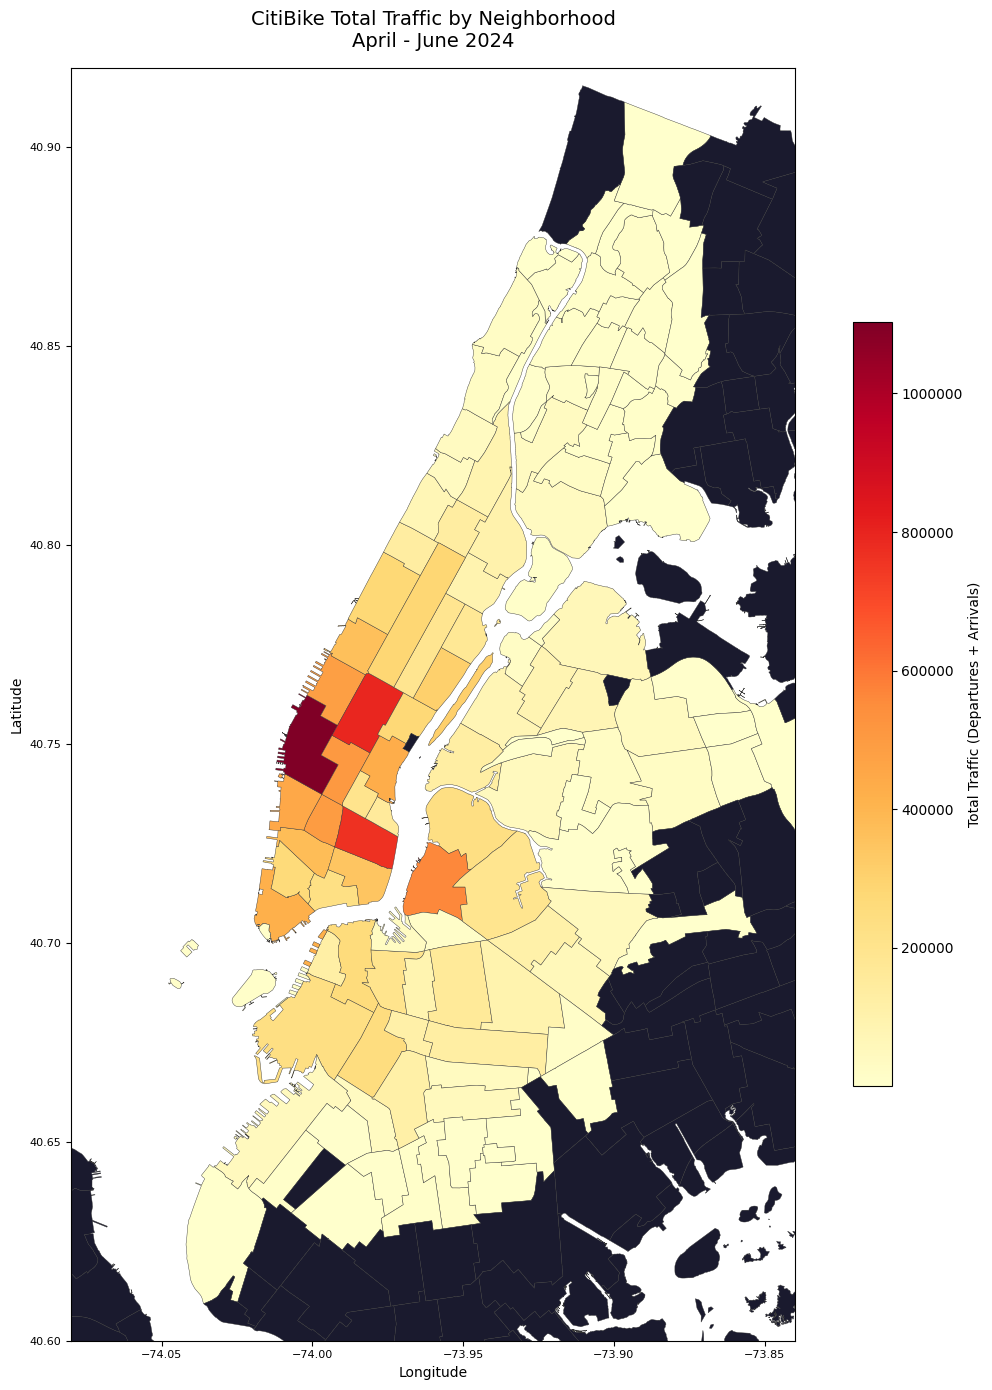

In [8]:
fig, ax = plt.subplots(figsize=(12, 14))

nta_geo.plot(
    ax=ax,
    column='total_traffic',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Total Traffic (Departures + Arrivals)',
                    'shrink': 0.6,
                    'format': '%.0f'},
    missing_kwds={'color': '#1a1a2e'},
    edgecolor='#333333',
    linewidth=0.3
)

ax.set_title('CitiBike Total Traffic by Neighborhood\nApril - June 2024', fontsize=14, pad=15)
ax.set_xlim(-74.08, -73.84)
ax.set_ylim(40.60, 40.92)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../figures/maps/choropleth_total_traffic.png', bbox_inches='tight')
plt.show()

## 4.3: Station Bubble Map

Visualize station-level traffic volume, where dot size and color both encode total traffic. Provides finer geographic granularity than choropleth, but confirms the same concentration patterns.

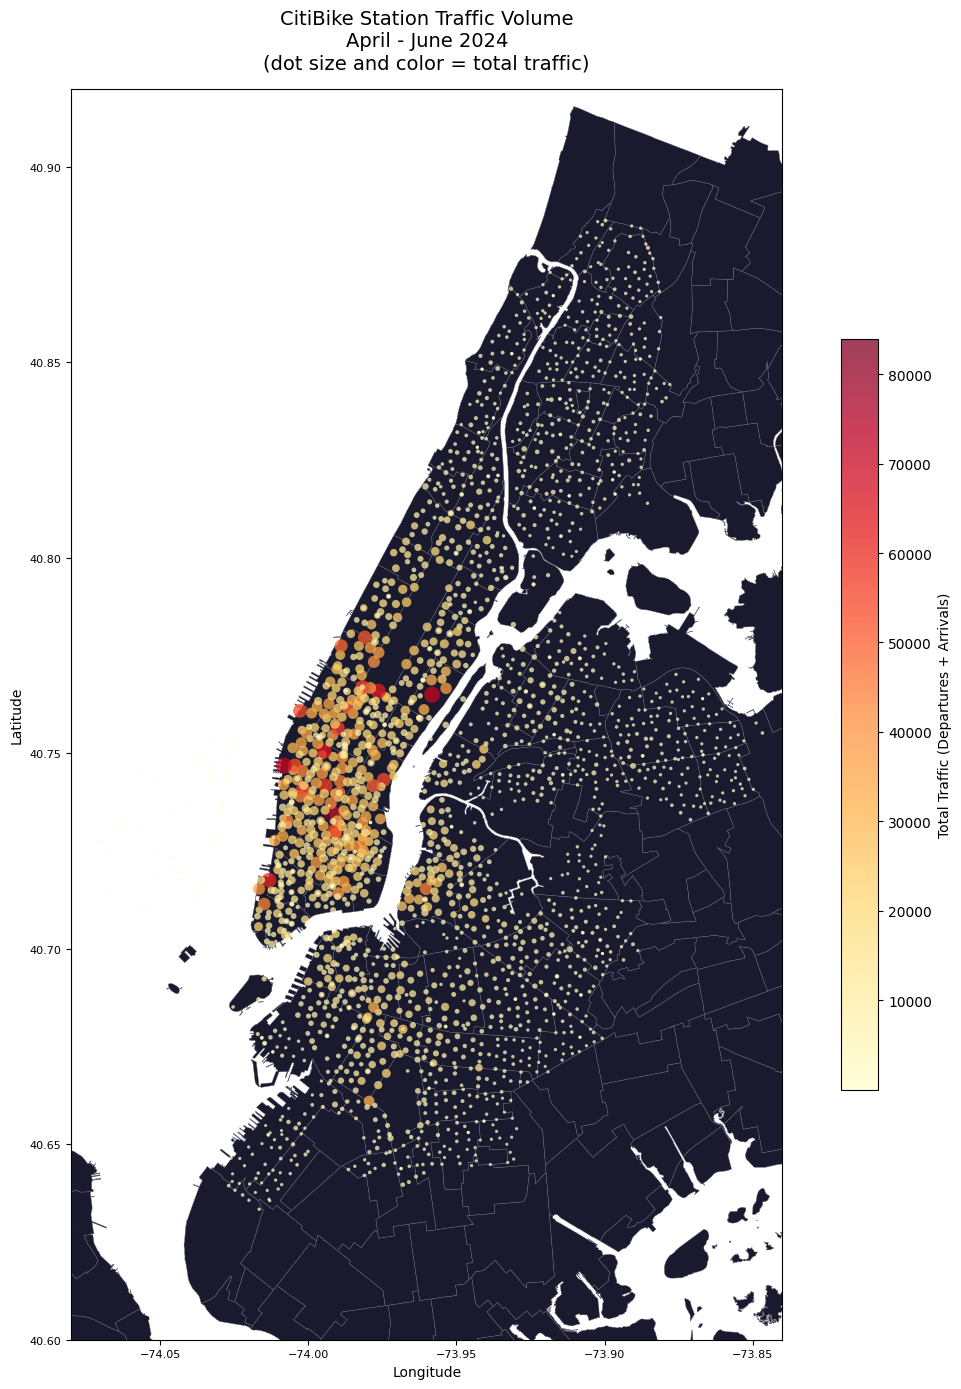

In [9]:
fig, ax = plt.subplots(figsize=(12, 14))

nta.plot(ax=ax, color='#1a1a2e', edgecolor="#646473", linewidth=0.3)

scatter = ax.scatter(
    stations_geo['start_lng'],
    stations_geo['start_lat'],
    c=stations_geo['total_traffic'],
    cmap='YlOrRd',
    s=stations_geo['total_traffic'] / stations_geo['total_traffic'].max() * 150 + 5,
    alpha=0.75,
    edgecolors='none'
)

plt.colorbar(scatter, ax=ax, label='Total Traffic (Departures + Arrivals)', shrink=0.6, format='%.0f')
ax.set_title('CitiBike Station Traffic Volume\nApril - June 2024\n(dot size and color = total traffic)',
        fontsize=14, pad=15)

ax.set_xlim(-74.08, -73.84)
ax.set_ylim(40.60, 40.92)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../figures/maps/station_bubble_map.png', bbox_inches='tight')

## 4.4: Station Flow Imbalance

One of the bigger issues CitiBike faces is the imbalance of bikes at stations. Stations are usually ones where few people depart from but many dock bikes, or ones where few people arrive but many take bikes from. Visualized by map showing the station flow imbalance, geographically mapping which stations see significantly more arrivals than departures, and vice versa. Puts into context how the issue of rebalancing cannot be addressed locally, as entire corridors share the same imbalance direction. City-scale redistribution is required to address the imbalance at a larger scale.

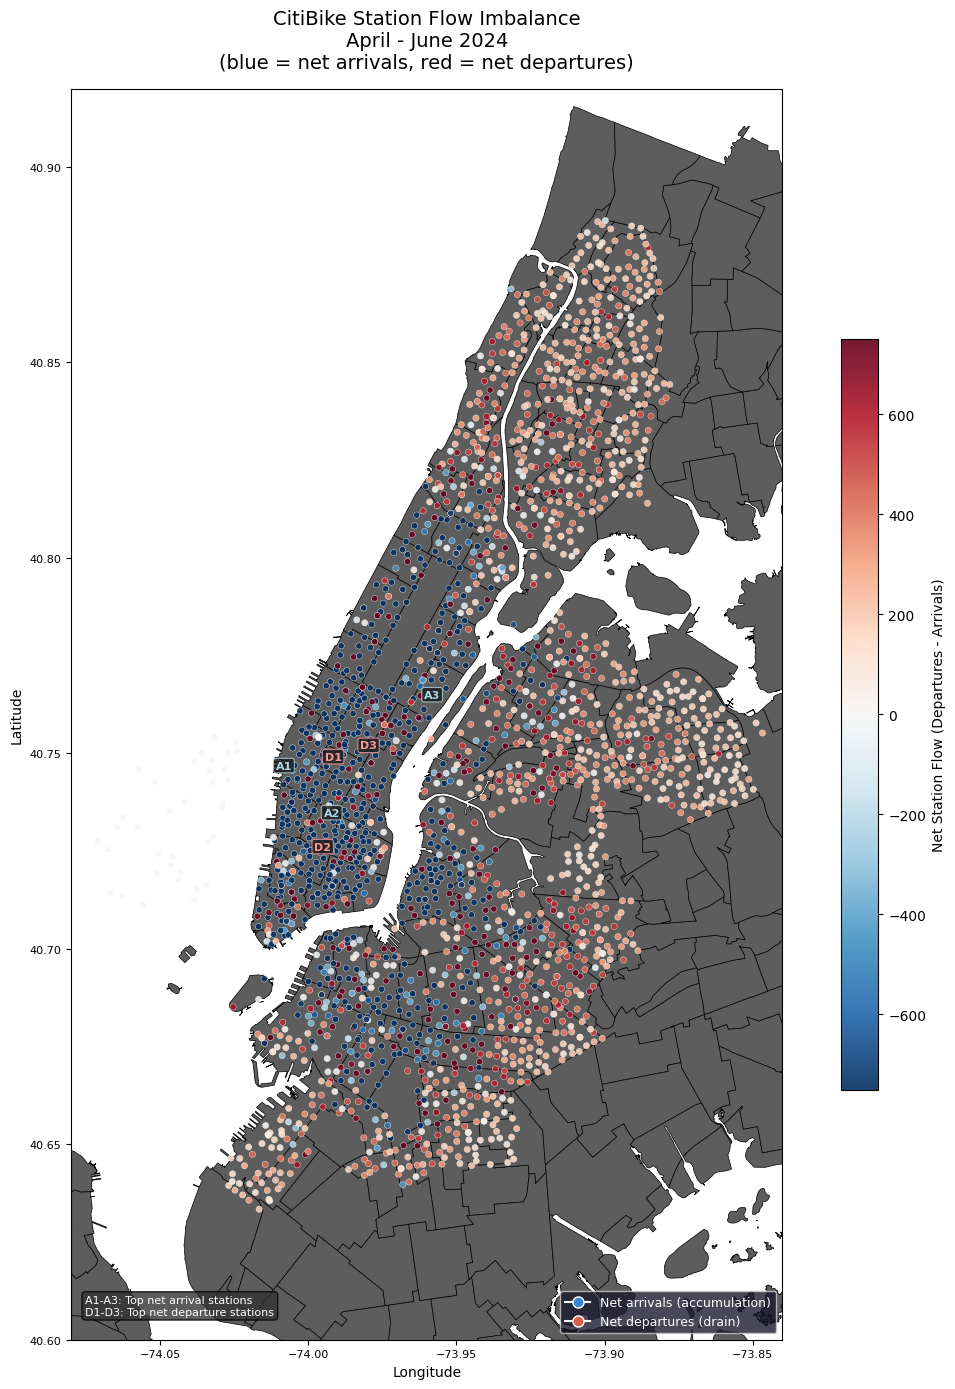

In [10]:
stations_geo['net_flow'] = (stations_geo['total_departures'] - stations_geo['total_arrivals'])

fig, ax = plt.subplots(figsize=(12, 14))
nta.plot(ax=ax, color="#5d5d5d", edgecolor="#000000", linewidth=0.5)

# diverging colormap centered at 0
divnorm = mcolors.TwoSlopeNorm(
    vmin=-750,
    vcenter=0,
    vmax=750
)

# plot configuration
scatter = ax.scatter(
    stations_geo['start_lng'],
    stations_geo['start_lat'],
    c=stations_geo['net_flow'],
    cmap='RdBu_r',
    norm=divnorm,
    s=20,
    alpha=0.9,
    edgecolors='white',
    linewidths=0.3
)

# annotate top 3 net arrival and departure stations
top_arrivals = stations_geo.nsmallest(3, 'net_flow').reset_index()
top_departures = stations_geo.nlargest(3, 'net_flow').reset_index()

# annotate top arrival stations (blue labels)
for i, row in top_arrivals.iterrows():
    ax.annotate(f'A{i+1}',
            xy=(row['start_lng'], row['start_lat']),
            fontsize=8, color='lightblue', fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', 
                    facecolor='#1a1a1a', 
                    alpha=0.8,
                    edgecolor='lightblue',
                	linewidth=0.8))

for i, row in top_departures.iterrows():
    ax.annotate(f'D{i+1}',
            xy=(row['start_lng'], row['start_lat']),
            fontsize=8, color='#ff9999', fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2',
                    facecolor='#1a1a1a',
                    alpha=0.8,
                    edgecolor='#ff9999',
                    linewidth=0.8))

legend_text = 'A1-A3: Top net arrival stations\nD1-D3: Top net departure stations'
ax.text(0.02, 0.02, legend_text,
    transform=ax.transAxes,
    fontsize=8, color='white',
    bbox=dict(boxstyle='round', facecolor='#333333', alpha=0.8))

# plot display
plt.colorbar(scatter, ax=ax, label='Net Station Flow (Departures - Arrivals)', shrink=0.6)
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#3986d2", markersize=8, label='Net arrivals (accumulation)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#d6604d', markersize=8, label='Net departures (drain)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, facecolor='#1a1a2e', labelcolor='white')
ax.set_title('CitiBike Station Flow Imbalance\nApril - June 2024\n(blue = net arrivals, red = net departures)',
            fontsize=14, pad=15)
ax.set_xlim(-74.08, -73.84)
ax.set_ylim(40.60, 40.92)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('../figures/maps/station_flow_imbalance.png', bbox_inches='tight')
plt.show()